# Words Frequency

In [ ]:
import json, pathlib, csv, re
from collections import Counter

# NLTK setup (robust)
import nltk
from nltk.corpus import stopwords
try:
    from nltk.tokenize import word_tokenize
except Exception:
    word_tokenize = None

def _ensure_nltk():
    # Try exact resources required by recent NLTK
    for pkg in ["stopwords", "punkt", "punkt_tab"]:
        try:
            nltk.data.find(f"corpora/{pkg}") if pkg=="stopwords" else nltk.data.find(f"tokenizers/{pkg}")
        except LookupError:
            nltk.download(pkg, quiet=True)

_ensure_nltk()

# After ensuring, import again (in case it failed earlier)
from nltk.corpus import stopwords
try:
    from nltk.tokenize import word_tokenize as _wt
    word_tokenize = _wt
except Exception:
    pass

EN_STOP = set(stopwords.words('english'))

# ---- config ----
PATH = pathlib.Path("data/newyorker_caption_contest/contests.json")
FIELDS = ["image_descriptions", "image_uncanny_descriptions", "image_locations", "questions"]
OUTDIR = pathlib.Path("data/GoogleTrends/frequent_words")

# Fallback regex tokenizer (letters only, >=3 chars)
TOKEN_RE = re.compile(r"[A-Za-z]{3,}")

def load_records(path: pathlib.Path):
    txt = path.read_text(encoding="utf-8")
    try:
        obj = json.loads(txt)
    except json.JSONDecodeError:
        recs = []
        with path.open(encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    recs.append(json.loads(line))
        return recs
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        if "contests" in obj and isinstance(obj["contests"], list):
            return obj["contests"]
        return [obj]
    raise ValueError("Unsupported JSON structure")

def collect_texts(records, field):
    out = []
    for r in records:
        m = r.get("metadata") or {}
        v = m.get(field) if isinstance(m, dict) else None
        if isinstance(v, list):
            out.extend([s for s in v if isinstance(s, str)])
        elif isinstance(v, str):
            out.append(v)
    return out

def tokenize_lower(text: str):
    """Prefer NLTK word_tokenize; fallback to regex if unavailable."""
    if word_tokenize is not None:
        try:
            return [w.lower() for w in word_tokenize(text)]
        except LookupError:
            # If punkt/punkt_tab still missing for some reason, fallback
            return [w.lower() for w in TOKEN_RE.findall(text)]
    else:
        return [w.lower() for w in TOKEN_RE.findall(text)]

def count_tokens_nltk(texts):
    c = Counter()
    for t in texts:
        tokens = tokenize_lower(t)
        # keep only alphabetic tokens, >=3 chars, not in stopwords
        filtered = [w for w in tokens if w.isalpha() and len(w) >= 3 and w not in EN_STOP]
        c.update(filtered)
    return c

def save_counts_csv(counter: Counter, out_path: pathlib.Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["token", "count"])
        for tok, freq in sorted(counter.items(), key=lambda kv: (-kv[1], kv[0])):
            w.writerow([tok, freq])

# ---- run ----
records = load_records(PATH)

for field in FIELDS:
    texts = collect_texts(records, field)
    counts = count_tokens_nltk(texts)
    outfile = OUTDIR / f"{field}__unigrams_nltk.csv"
    save_counts_csv(counts, outfile)


## Visualize the frequency

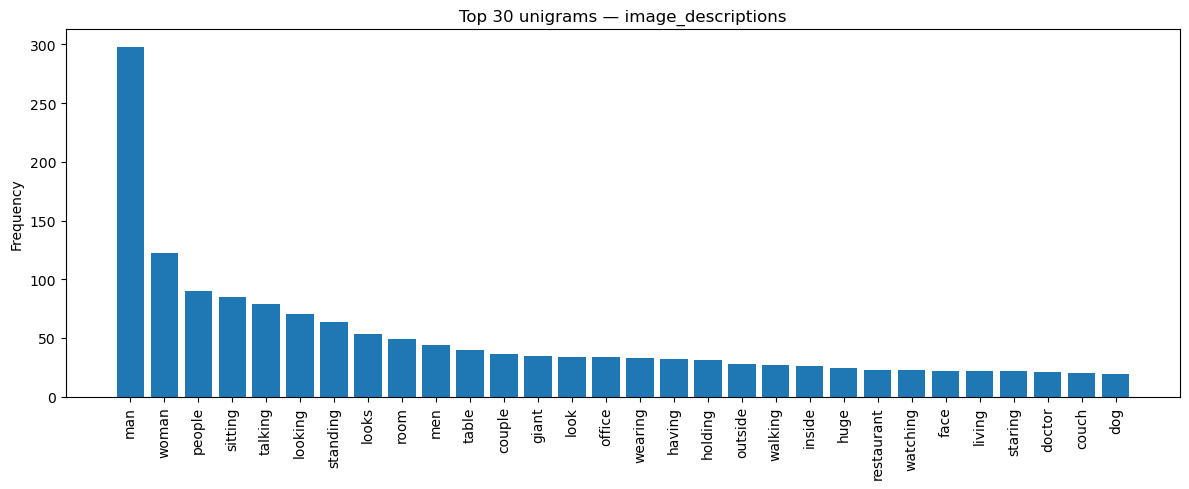

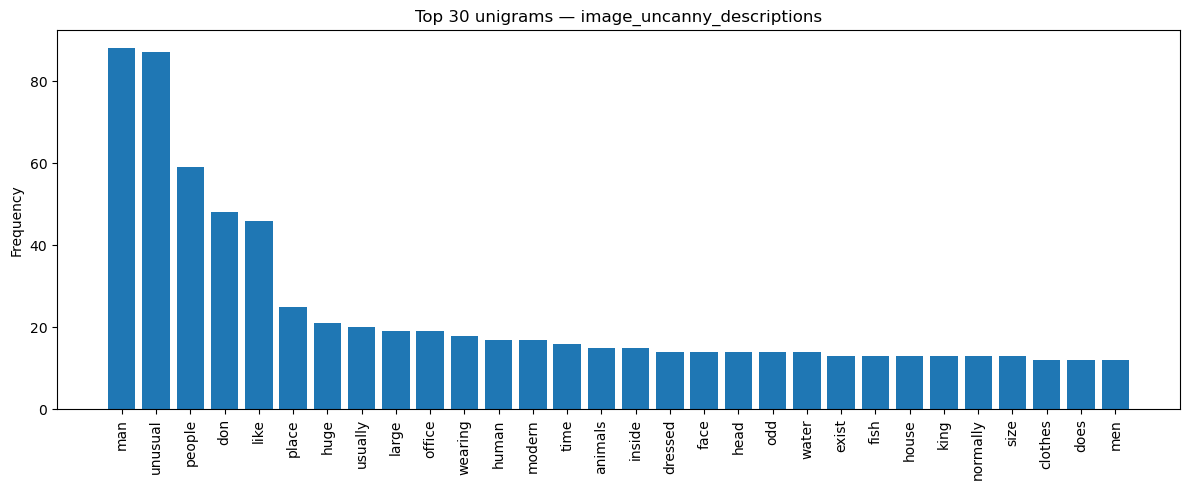

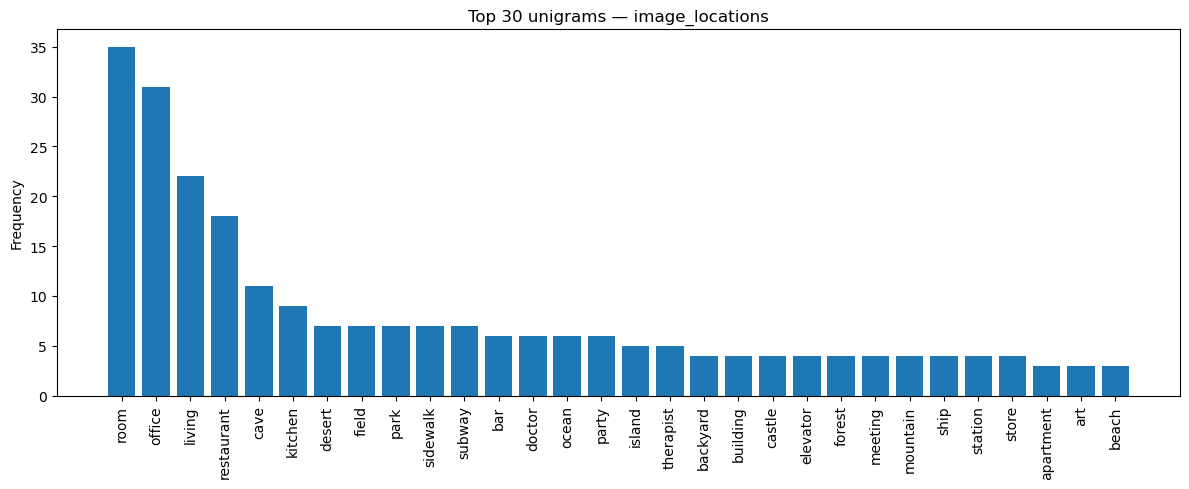

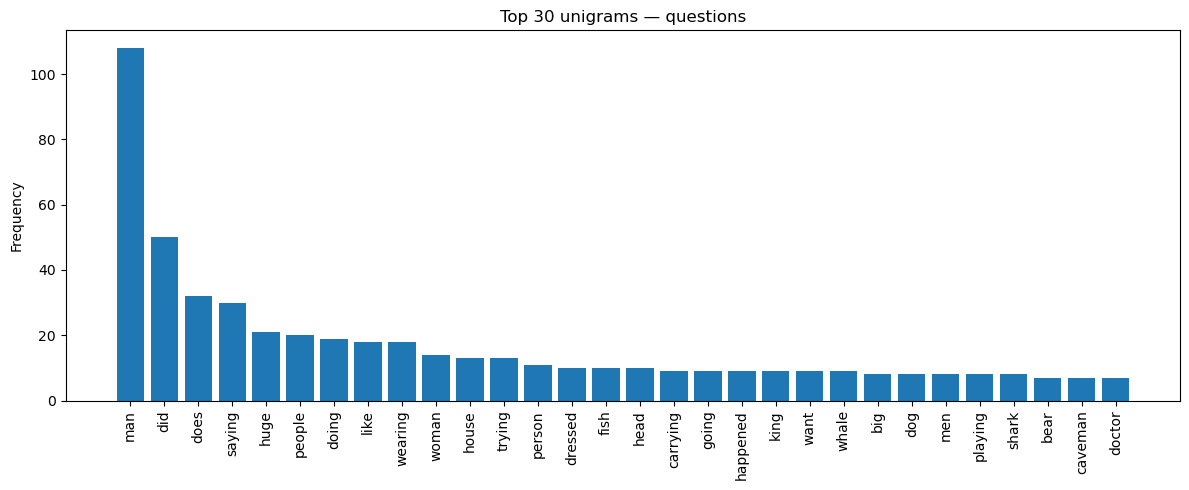

In [37]:
def load_records(path: pathlib.Path):
    txt = path.read_text(encoding="utf-8")
    try:
        obj = json.loads(txt)
    except json.JSONDecodeError:
        # JSONL fallback
        recs = []
        with path.open(encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    recs.append(json.loads(line))
        return recs
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        if "contests" in obj and isinstance(obj["contests"], list):
            return obj["contests"]
        return [obj]
    raise ValueError("Unsupported JSON structure")

def collect_texts(records, field: str) -> List[str]:
    out = []
    for r in records:
        m = r.get("metadata") or {}
        v = m.get(field) if isinstance(m, dict) else None
        if isinstance(v, list):
            out.extend([s for s in v if isinstance(s, str)])
        elif isinstance(v, str):
            out.append(v)
    return out

# --- Run per field ---
records = load_records(PATH)

for field in FIELDS:
    texts = collect_texts(records, field)
    if not texts:
        print(f"[{field}] No texts found, skipping.")
        continue

    vectorizer = CountVectorizer(
        stop_words="english",
        token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
        ngram_range=NGRAM_RANGE
    )
    X = vectorizer.fit_transform(texts)               # sparse [n_docs, n_vocab]
    counts = np.asarray(X.sum(axis=0)).ravel()        # total counts per vocab term
    vocab = np.array(vectorizer.get_feature_names_out())

    # sort by frequency desc, then term asc
    order = np.lexsort((vocab, -counts))
    top_idx = order[:TOP_K]
    top_terms = vocab[top_idx]
    top_counts = counts[top_idx]

    # Plot one figure per field
    plt.figure(figsize=(12, 5))
    plt.bar(top_terms, top_counts)
    plt.xticks(rotation=90)
    ngram_label = "unigrams" if NGRAM_RANGE == (1,1) else f"{NGRAM_RANGE[0]}-{NGRAM_RANGE[1]}-grams"
    plt.title(f"Top {TOP_K} {ngram_label} — {field}")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


## Visualize the cluster


=== image_descriptions — KMeans(k=20) top terms per cluster ===
Cluster 00: doctor, patient, note, gingerbread, speaking, clipboard, dejected, king, examination, looks
Cluster 01: standing, sharks, cooking, man, nearby, kitchen, knight, subway, people, suit
Cluster 02: room, living, people, sitting, outside, women, looking, house, woman, window
Cluster 03: woman, man, party, sized, huge, room, talking, chair, yoga, legs
Cluster 04: table, couple, board, sitting, man, jack, restaurant, executives, frankenstein, beanstalk
Cluster 05: doctor, man, wearing, snake, office, wrapped, large, talking, king, hospital
Cluster 06: carrying, men, man, business, briefcase, big, walking, tubas, hall, cliff
Cluster 07: judge, lawyer, bear, witness, courtroom, teddy, looks, stand, traps, client
Cluster 08: fish, bar, bartender, talking, mouse, humpty, dumpty, turtle, pigeon, offers
Cluster 09: desk, door, office, sword, middle, men, looking, woman, stuck, talking
Cluster 10: couch, office, psychiatris

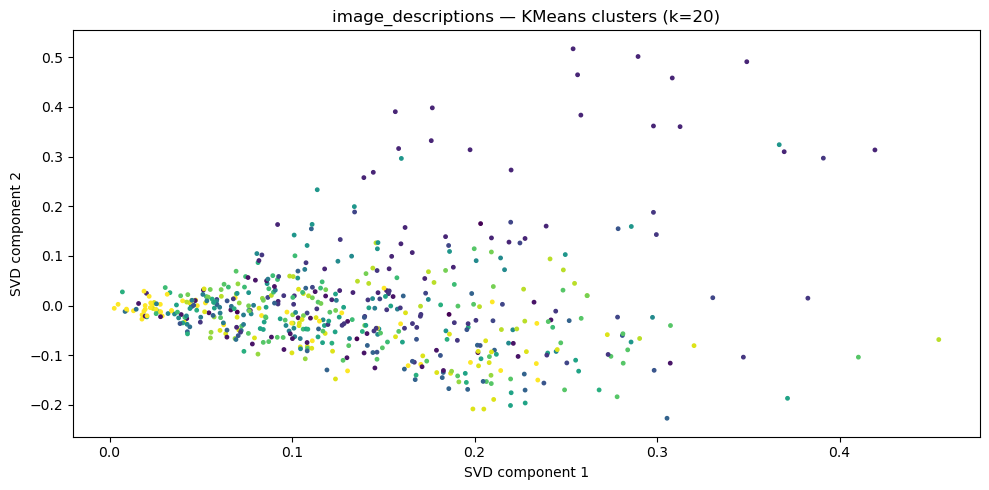


=== image_uncanny_descriptions — KMeans(k=20) top terms per cluster ===
Cluster 00: giant, earth, huge, rat, color, inside, water, impossible, fit, room
Cluster 01: man, mountain, food, piano, huge, dressed, looking, egg, sitting, gigantic
Cluster 02: unusual, wearing, man, human, horse, size, thing, holding, clothing, shoes
Cluster 03: kitchen, traps, knight, hazmat, suit, medieval, trapped, booby, armor, lock
Cluster 04: like, looks, man, dressed, acting, hamster, diving, leaves, people, dolphins
Cluster 05: men, bar, typically, larger, aren, wear, don, way, whales, people
Cluster 06: don, mice, cats, live, like, build, mazes, maze, walk, intelligent
Cluster 07: odd, doing, magic, magician, public, unicorns, trick, watching, alley, people
Cluster 08: place, really, office, stands, ufos, horses, time, taking, table, image
Cluster 09: long, hair, woman, supposed, rapunzel, man, does, guard, mosquitoes, carrying
Cluster 10: time, modern, period, belong, woman, knight, doesn, wrong, kni

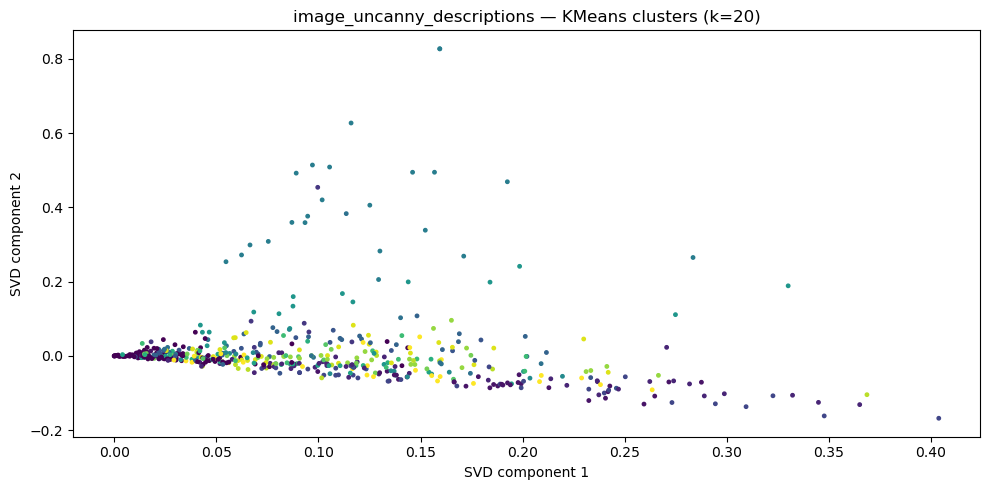


=== image_locations — KMeans(k=20) top terms per cluster ===
Cluster 00: ocean, yoga, funeral, hard, hamster, hall, ground, grocery, graveyard, golf
Cluster 01: living, room, forest, hamster, hall, ground, grocery, graveyard, golf, gas
Cluster 02: sidewalk, yoga, forest, hamster, hall, ground, grocery, graveyard, golf, gas
Cluster 03: field, baseball, yoga, gallery, hard, hamster, hall, ground, grocery, graveyard
Cluster 04: office, doctor, therapist, psychiatry, psychiatrist, police, psychologist, work, desk, corporate
Cluster 05: forest, yoga, gallery, hard, hamster, hall, ground, grocery, graveyard, golf
Cluster 06: restaurant, yoga, funeral, hamster, hall, ground, grocery, graveyard, golf, gas
Cluster 07: bar, funeral, hard, hamster, hall, ground, grocery, graveyard, golf, gas
Cluster 08: backyard, yoga, funeral, hard, hamster, hall, ground, grocery, graveyard, golf
Cluster 09: park, bench, public, heaven, hard, hamster, hall, ground, grocery, graveyard
Cluster 10: cave, dwelling,

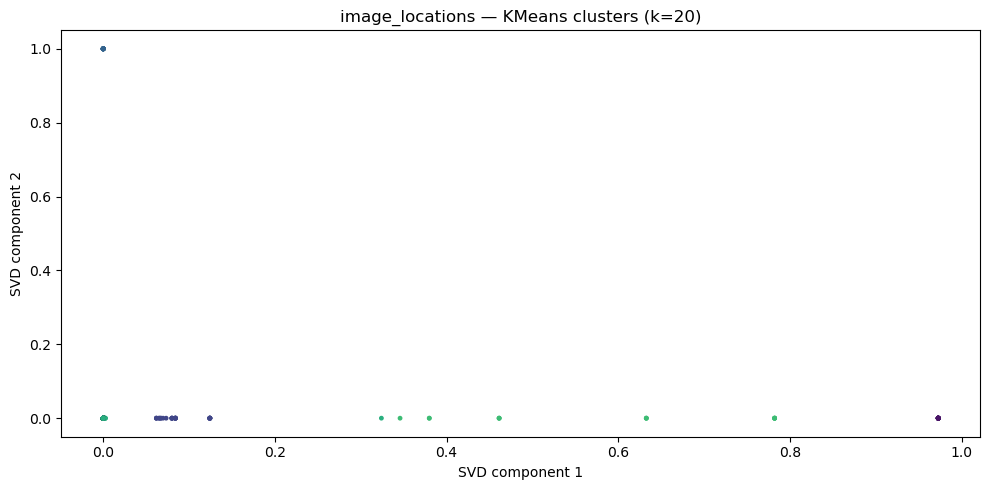


=== questions — KMeans(k=20) top terms per cluster ===
Cluster 00: huge, man, carrying, snake, frill, mosquitoes, umbrella, dogs, halo, does
Cluster 01: man, saying, gingerbread, drunk, isn, mobster, happy, shark, cat, woman
Cluster 02: beach, ball, large, flooded, book, balls, dead, caused, colored, did
Cluster 03: king, doctor, office, writing, city, man, actually, paper, going, informally
Cluster 04: big, waiter, bringing, garbage, table, hornets, overly, menu, patron, snail
Cluster 05: wearing, person, armor, horse, suit, propeller, hat, shark, stand, roller
Cluster 06: room, monkeys, living, baseball, playing, people, slanted, sheep, corner, mat
Cluster 07: happened, groomsman, leg, death, city, tattered, cause, driven, clothes, drink
Cluster 08: talking, bartender, turtle, mouse, family, falling, fall, faces, face, fable
Cluster 09: people, watching, just, inside, burning, tiny, dealing, cannonballing, man, bubbles
Cluster 10: head, eating, blender, lion, does, man, dead, subway

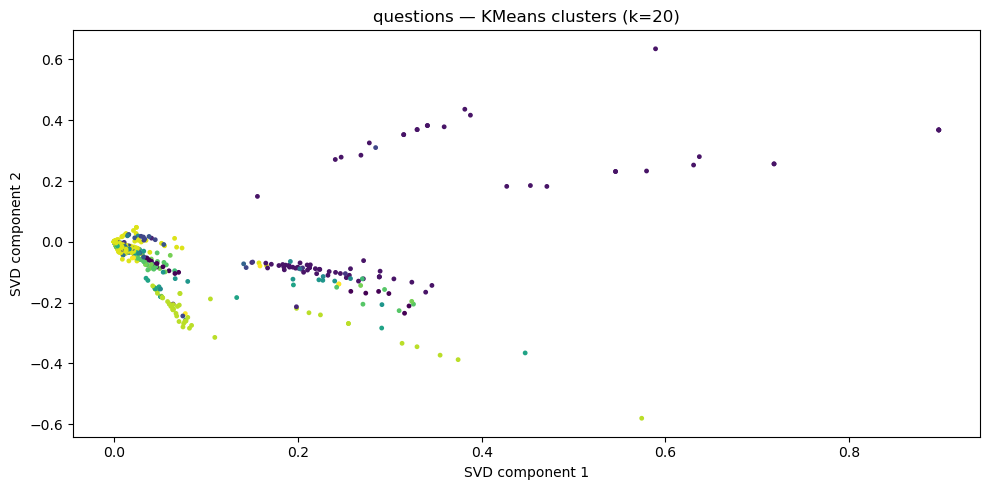

In [48]:
import json, pathlib
from typing import List, Tuple
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

# --- Config ---
PATH = pathlib.Path("data/newyorker_caption_contest/contests.json")
FIELDS = ["image_descriptions", "image_uncanny_descriptions", "image_locations", "questions"]
MAX_FEATURES = 5000
DEFAULT_NUM_CLUSTERS = 20
MIN_DOCS_FOR_CLUSTERING = 10      # skip clustering if fewer docs than this
TOP_TERMS_PER_CLUSTER = 10        # how many top words to show per cluster
RANDOM_STATE = 42

# --- Load & normalize JSON ---
def load_records(path: pathlib.Path):
    txt = path.read_text(encoding="utf-8")
    try:
        obj = json.loads(txt)
    except json.JSONDecodeError:
        recs = []
        with path.open(encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    recs.append(json.loads(line))
        return recs
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        if "contests" in obj and isinstance(obj["contests"], list):
            return obj["contests"]
        return [obj]
    raise ValueError("Unsupported JSON structure")

def collect_texts(records, field: str) -> List[str]:
    out = []
    for r in records:
        m = r.get("metadata") or {}
        v = m.get(field) if isinstance(m, dict) else None
        if isinstance(v, list):
            out.extend([s for s in v if isinstance(s, str)])
        elif isinstance(v, str):
            out.append(v)
    # basic cleanup: strip; drop empty
    out = [t.strip() for t in out if isinstance(t, str) and t.strip()]
    return out

def fit_tfidf(texts: List[str]) -> Tuple[TfidfVectorizer, np.ndarray]:
    vec = TfidfVectorizer(
        stop_words="english",
        max_features=MAX_FEATURES,
        token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",  # words with >=3 letters
    )
    X = vec.fit_transform(texts)  # sparse matrix
    return vec, X

def auto_num_clusters(n_docs: int) -> int:
    # heuristic: up to DEFAULT_NUM_CLUSTERS, but never more than n_docs//5 and at least 2
    k = min(DEFAULT_NUM_CLUSTERS, max(2, n_docs // 5))
    return min(k, n_docs) if n_docs >= 2 else 0

def top_terms_per_cluster(kmeans: KMeans, vectorizer: TfidfVectorizer, top_n: int = 10):
    # approximate interpretability: use cluster centers to pick top-weighted features
    terms = vectorizer.get_feature_names_out()
    centers = kmeans.cluster_centers_
    for i, c in enumerate(centers):
        top_idx = np.argsort(c)[::-1][:top_n]
        yield i, [terms[j] for j in top_idx]

def plot_clusters_2d(X_sparse, labels, title: str):
    svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
    X_2d = svd.fit_transform(X_sparse)  # works on sparse
    plt.figure(figsize=(10, 5))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=6, cmap="viridis")
    plt.title(title)
    plt.xlabel("SVD component 1")
    plt.ylabel("SVD component 2")
    plt.tight_layout()
    plt.show()

# --- Run per field ---
records = load_records(PATH)

for field in FIELDS:
    texts = collect_texts(records, field)
    n_docs = len(texts)
    if n_docs < MIN_DOCS_FOR_CLUSTERING:
        print(f"[{field}] Not enough documents ({n_docs}) — skipping clustering.")
        continue

    vectorizer, X_tfidf = fit_tfidf(texts)
    k = auto_num_clusters(n_docs)
    if k < 2:
        print(f"[{field}] Not enough documents for clustering — skipping.")
        continue

    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_tfidf)
    labels = kmeans.labels_

    # Print top terms per cluster (interpretation)
    print(f"\n=== {field} — KMeans(k={k}) top terms per cluster ===")
    for cid, terms in top_terms_per_cluster(kmeans, vectorizer, TOP_TERMS_PER_CLUSTER):
        print(f"Cluster {cid:02d}: {', '.join(terms)}")

    # Plot 2D clusters
    plot_clusters_2d(X_tfidf, labels, f"{field} — KMeans clusters (k={k})")


## Extract google trend data from march 2016 to september 2023

In [61]:
# === Google Trends for ALL tokens from your four CSVs ===
from pytrends.request import TrendReq
import pandas as pd
import numpy as np
from pathlib import Path
import time

# ---------- CONFIG ----------
CSV_DIR = Path("data/GoogleTrends/frequent_words")
FIELD_PREFIXES = [
    "image_descriptions",
    "image_uncanny_descriptions",
    "image_locations",
    "questions",
]
# We'll read ANY CSV that starts with one of the prefixes (so works with both nltk/non-nltk filenames)
TIMEFRAME = "2016-03-01 2023-09-30"   # March 2016 → September 2023
GEO = "US"                            # set "" for worldwide
BATCH_SIZE = 5                        # Google Trends limit per request
SLEEP_SEC = 2.0                       # politeness delay between calls
RETRY = 2                             # retry per batch on transient errors
MIN_TOKEN_LEN = 3                     # ignore ultra-short tokens
SAVE_PATH = Path("data/GoogleTrends/google_trends_ALL_tokens_2016_03_to_2023_09_US.csv")
# ----------------------------

def read_tokens_from_csvs(csv_dir: Path, prefixes):
    tokens = []
    for pref in prefixes:
        for p in csv_dir.glob(f"{pref}__*.csv"):
            df = pd.read_csv(p)
            if "token" not in df.columns:
                continue
            toks = (
                df["token"]
                .astype(str)
                .map(str.strip)
                .replace("", np.nan)
                .dropna()
                .tolist()
            )
            tokens.extend(toks)
    # de-duplicate preserving order; enforce min length
    seen = set()
    result = []
    for t in tokens:
        t_low = t.lower()
        if len(t_low) >= MIN_TOKEN_LEN and t_low not in seen:
            seen.add(t_low)
            result.append(t)
    return result

def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i : i + n]

# 1) Collect ALL tokens
keywords = read_tokens_from_csvs(CSV_DIR, FIELD_PREFIXES)
if not keywords:
    raise ValueError(f"No tokens found in {CSV_DIR} for prefixes {FIELD_PREFIXES}")

print(f"Total unique keywords to fetch: {len(keywords)}")

# 2) Query Google Trends in batches (≤5)
pytrends = TrendReq(hl="en-US", tz=360)
frames = []
failed_batches = []

for batch in chunks(keywords, BATCH_SIZE):
    ok = False
    err = None
    for attempt in range(1, RETRY + 2):  # first try + retries
        try:
            pytrends.build_payload(kw_list=batch, timeframe=TIMEFRAME, geo=GEO)
            df = pytrends.interest_over_time()
            if "isPartial" in df.columns:
                df = df.drop(columns=["isPartial"])
            frames.append(df)
            ok = True
            break
        except Exception as e:
            err = e
            time.sleep(SLEEP_SEC * attempt)  # exponential-ish backoff
    if not ok:
        failed_batches.append((batch, repr(err)))
    time.sleep(SLEEP_SEC)

# 3) Merge results
if not frames:
    raise RuntimeError("No data returned from Google Trends. (All batches failed.)")

trends_wide = frames[0]
for df in frames[1:]:
    trends_wide = trends_wide.join(df, how="outer")

# Sort by date and fill missing with 0 (optional)
trends_wide = trends_wide.sort_index().fillna(0).astype(int)

# 4) Save single CSV (one column per keyword)
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
trends_wide.to_csv(SAVE_PATH)
print(f"Saved trends to: {SAVE_PATH.resolve()}  with shape {trends_wide.shape}")

# 5) Minimal report on failures (if any)
if failed_batches:
    print("\nSome batches failed (columns missing for these keywords):")
    for batch, e in failed_batches:
        print(f"- {batch} -> {e}")

# 6) Quick sanity peek (first 5 columns & rows)
display(trends_wide.iloc[:5, :5])


Total unique keywords to fetch: 2263
Saved trends to: /Users/yann/Desktop/EPFL Master/Applied Data Analysis/ada-2025-project-data_dinosaur/data/processed/google_trends_ALL_tokens_2016_03_to_2023_09_US.csv  with shape (91, 2258)

Some batches failed (columns missing for these keywords):
- ['sheep', 'side', 'subway', 'taking', 'train'] -> TooManyRequestsError('The request failed: Google returned a response with code 429')


,man,two,woman,people,one
date,,,,,
2016-03-01,42,27,20,42,76
2016-04-01,42,26,20,42,80
2016-05-01,44,24,19,40,78
2016-06-01,42,22,19,38,77
2016-07-01,42,20,19,38,75


In [63]:
import pandas as pd
from pathlib import Path

# --- Config ---
INPUT_WIDE_CSV = Path("data/GoogleTrends/google_trends_ALL_tokens_2016_03_to_2023_09_US.csv")  # adjust if needed
OUTPUT_MEANS_CSV = Path("data/GoogleTrends/google_trends_means_2016_03_to_2023_09_US.csv")

# Use existing trends_wide if present; else load from CSV
if "trends_wide" in globals():
    df = trends_wide.copy()
else:
    # First column is the date index in the saved file
    df = pd.read_csv(INPUT_WIDE_CSV, index_col=0, parse_dates=True)

# Keep only numeric columns (keywords)
num = df.select_dtypes(include="number")

# Compute mean interest per keyword across the full timeframe
means = num.mean(axis=0, skipna=True)

# In case of any accidental duplicate column names, average them
means = means.groupby(level=0).mean()

# Build tidy result and sort
out = (
    means.reset_index()
         .rename(columns={"index": "token", 0: "mean_interest"})
         .sort_values("mean_interest", ascending=False)
         .reset_index(drop=True)
)

out["mean_interest"] = out["mean_interest"].round(3)

# Save
OUTPUT_MEANS_CSV.parent.mkdir(parents=True, exist_ok=True)
out.to_csv(OUTPUT_MEANS_CSV, index=False)


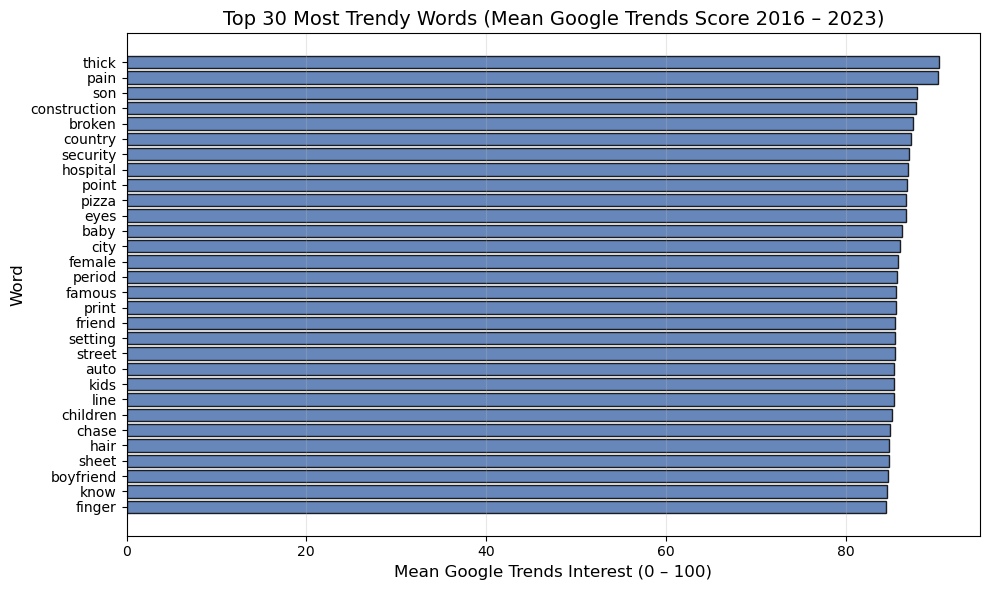

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- Load Google Trends mean scores ---
FILE = Path("data/GoogleTrends/google_trends_means_2016_03_to_2023_09_US.csv")
df = pd.read_csv(FILE)

# --- Prepare top 10 trendy words ---
df = df.sort_values("mean_interest", ascending=False).reset_index(drop=True)
top10 = df.head(30)

# --- Plot ---
plt.figure(figsize=(10,6))
bars = plt.barh(top10["token"], top10["mean_interest"], color="#4C72B0", edgecolor="black", alpha=0.85)
plt.gca().invert_yaxis()  # highest on top
plt.title("Top 30 Most Trendy Words (Mean Google Trends Score 2016 – 2023)", fontsize=14)
plt.xlabel("Mean Google Trends Interest (0 – 100)", fontsize=12)
plt.ylabel("Word", fontsize=12)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()